## PROYECTO 3

### Imports

In [ ]:
import torch
import os
import matplotlib.pyplot as plt
import pytorch_lightning as pl
from PIL import Image
from collections import defaultdict
import wandb
from Unet import UNet
from VAE import VAE
from latent_analysis import *

## Dataset

### Análisis de distribución

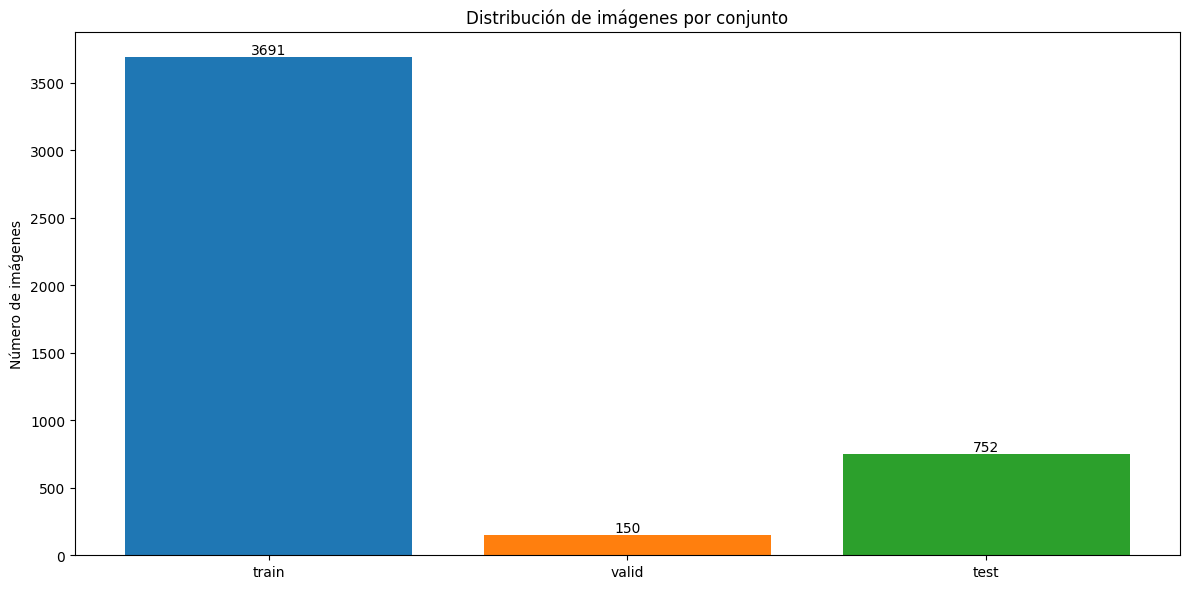

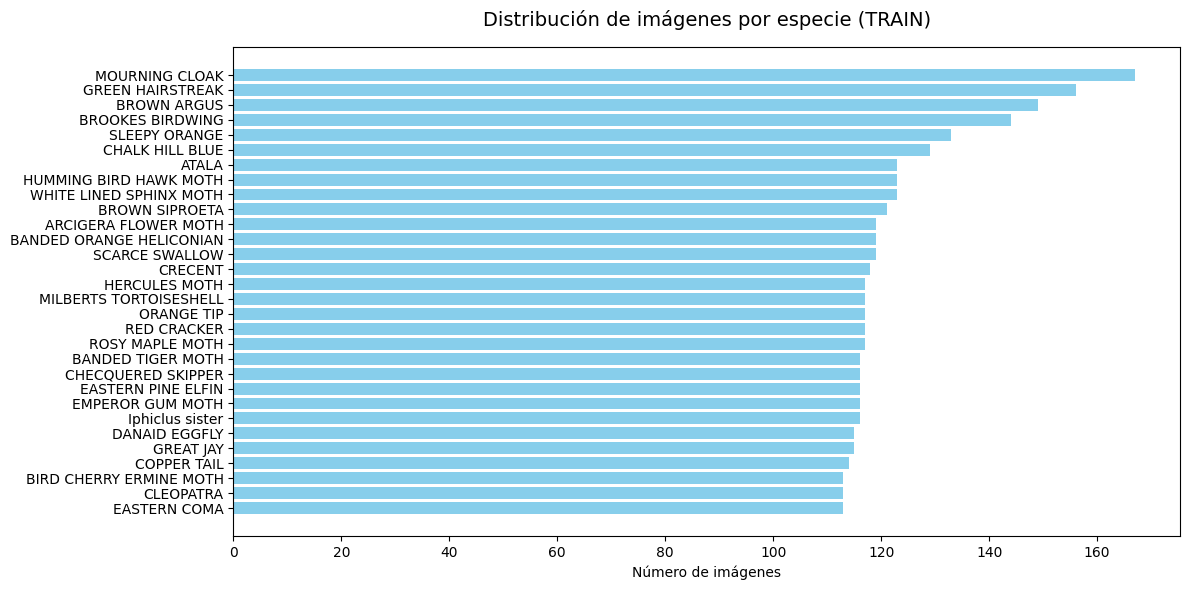

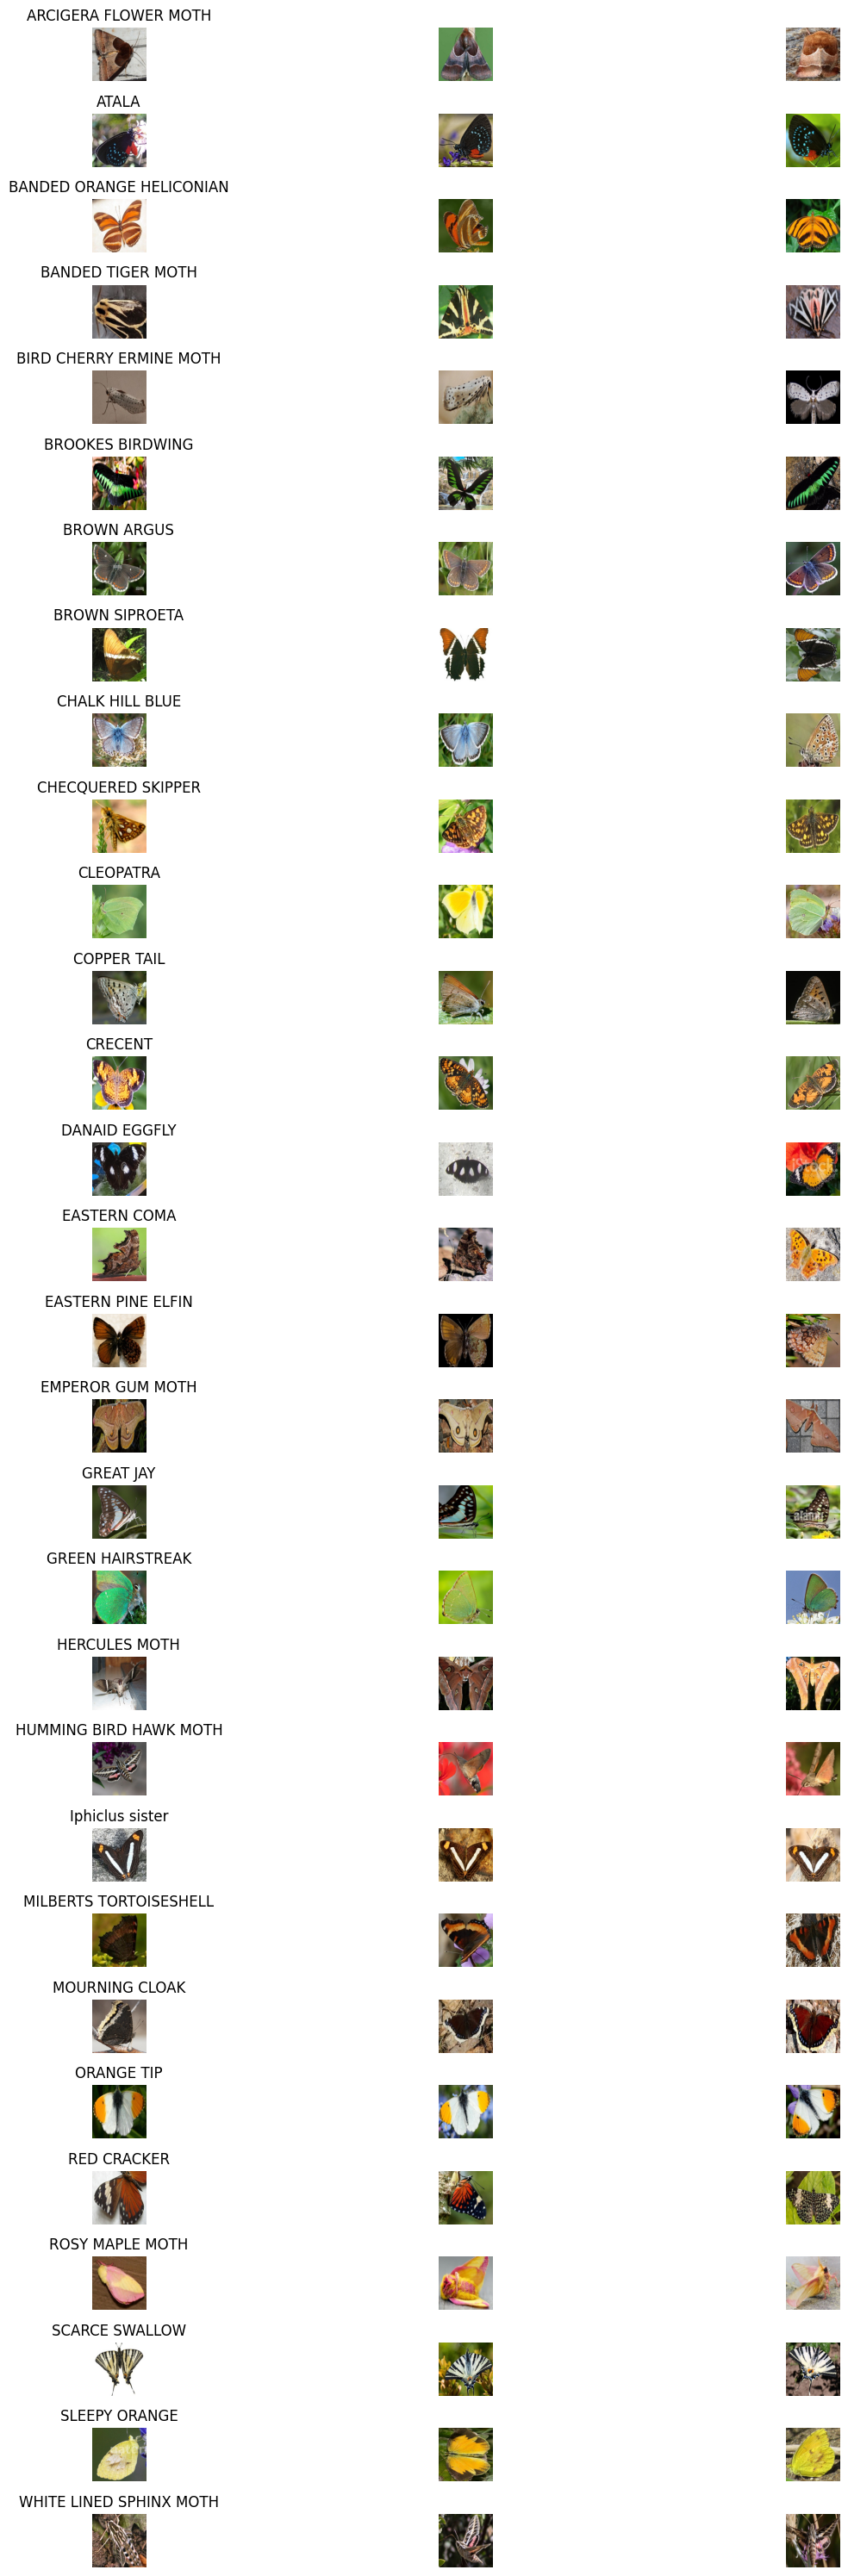

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


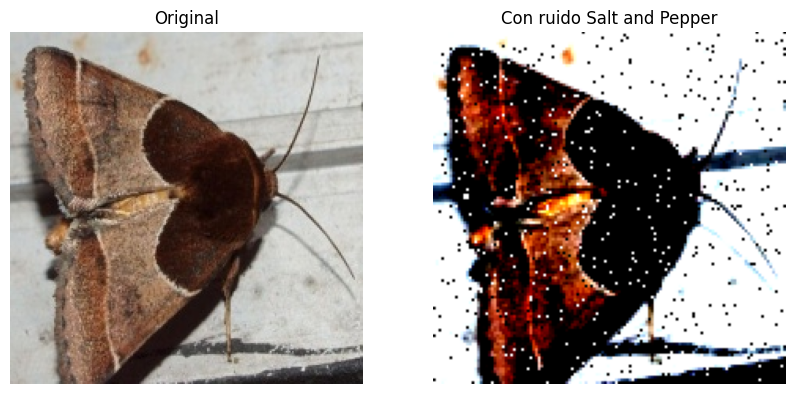

In [2]:
# Análisis de estructura
def analyze_dataset_structure(base_path="dataset"):
    splits = ['train', 'valid', 'test']
    structure = {split: defaultdict(int) for split in splits}
    
    for split in splits:
        split_path = os.path.join(base_path, split)
        for species in os.listdir(split_path):
            species_path = os.path.join(split_path, species)
            if os.path.isdir(species_path):
                num_images = len([f for f in os.listdir(species_path) if f.lower().endswith('.jpg')])
                structure[split][species] = num_images
    return structure

dataset_structure = analyze_dataset_structure()

# Importaciones de los módulos
from utils.data_module import ButterflyDataModule
from utils.transforms import get_denoising_transform
from utils.visualization import plot_distribution, plot_samples_per_species, display_sample_images

# Inicialización y verificación
datamodule = ButterflyDataModule(data_root="dataset", batch_size=32)
datamodule.setup()

# Visualizaciones
plot_distribution(dataset_structure)
plot_samples_per_species(dataset_structure, split='train')
display_sample_images(datamodule.train_dataset, n_samples=3)

# Ejemplo de transformación de denoising
sample_img = Image.open(datamodule.train_dataset.samples[0][0])
noisy_img = get_denoising_transform()(sample_img)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sample_img)
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(noisy_img.permute(1, 2, 0))
plt.title("Con ruido Salt and Pepper")
plt.axis('off')
plt.show()

### Usage of Unet

In [3]:
model = UNet(in_channels=3, out_channels=3)  # Reconstrucción RGB
output = model(torch.randn(1, 3, 128, 128))  # input tensor de prueba
print(output.shape)  # Debe dar (1, 3, 128, 128)

torch.Size([1, 3, 128, 128])


### Noise

In [4]:
def add_salt_pepper_noise(image, amount=0.02):
    noisy = image.clone()
    probs = torch.rand_like(noisy)
    noisy[probs < amount / 2] = 0.0  # Sal
    noisy[probs > 1 - amount / 2] = 1.0  # Pimienta
    return noisy